# Task 1

In [65]:
!pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
from dotenv import load_dotenv
import os

load_dotenv()  # laddar .env-filen

True

In [67]:
from dotenv import load_dotenv
import os

load_dotenv()  # laddar .env-filen

True

In [68]:
api_key = os.getenv("API")



In [69]:
print(api_key[:5] + "...")

b80a2...


# Task 2

In [70]:
# Package download
!pip install requests pandas 

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### a.

In [71]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

In [72]:
# Load environment variables
load_dotenv()
api_key = os.getenv("API")  # change if you used another variable name

# Endpoint
url = "https://api.marketstack.com/v1/eod"

# FAANG tickers for the assignment
symbols = "META,AAPL,AMZN,NFLX,GOOG"

params = {
    "access_key": api_key,
    "symbols": symbols,
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "sort": "ASC"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()


In [73]:
# Just to visualize the data
print(data)

{'pagination': {'limit': 100, 'offset': 0, 'count': 100, 'total': 100}, 'data': [{'open': 262.44, 'high': 266.53, 'low': 260.2, 'close': 264.72, 'volume': 41576035.0, 'adj_high': 266.53, 'adj_low': 260.2, 'adj_close': 264.72, 'adj_open': 262.41, 'adj_volume': 41827946.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2026-03-02T00:00:00+0000'}, {'open': 204.55, 'high': 209.72, 'low': 203.48, 'close': 208.39, 'volume': 43410499.0, 'adj_high': 209.73, 'adj_low': 203.46, 'adj_close': 208.39, 'adj_open': 204.55, 'adj_volume': 46001010.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AMZN', 'exchange': 'XNAS', 'date': '2026-03-02T00:00:00+0000'}, {'open': 302.93, 'high': 308.14, 'low': 301.06, 'close': 306.36, 'volume': 21789144.0, 'adj_high': 308.14, 'adj_low': 301.06, 'adj_close': 306.36, 'adj_open': 302.965, 'adj_volume': 21854368.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'GOOG', 'exchange': 'XNAS', 'date': '2026-03-02T00:00:00+0000'}, {'

## b

In [74]:
# Convert JSON to DataFrame
df = pd.DataFrame(data["data"])

# Print first 5 rows
print(df.head(5))

     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  262.44  266.53  260.20  264.72  41576035.0    266.53   260.20     264.72   
1  204.55  209.72  203.48  208.39  43410499.0    209.73   203.46     208.39   
2  302.93  308.14  301.06  306.36  21789144.0    308.14   301.06     306.36   
3  637.16  659.94  634.50  653.56   9801700.0    659.94   634.50     653.56   
4   95.33   98.07   95.25   97.09  79614084.0     98.07    95.20      97.09   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0   262.410  41827946.0           1.0       0.0   AAPL     XNAS   
1   204.550  46001010.0           1.0       0.0   AMZN     XNAS   
2   302.965  21854368.0           1.0       0.0   GOOG     XNAS   
3   637.160   9816125.0           1.0       0.0   META     ARCX   
4    95.260  79915361.0           1.0       0.0   NFLX     XNAS   

                       date  
0  2026-03-02T00:00:00+0000  
1  2026-03-02T00:00:00+0000  
2  2026-03-02T00:00:00+0000  
3 

## c

In [75]:
# Summary statistics for closing prices
summary_stats = df.groupby("symbol")["close"].describe()

print(summary_stats)

        count      mean        std     min       25%      50%       75%  \
symbol                                                                    
AAPL     20.0  255.3760   5.445847  247.99  251.1475  253.560  260.4200   
AMZN     20.0  210.5335   4.365905  199.34  208.2100  210.005  213.2800   
GOOG     20.0  299.7785   9.466742  273.76  298.6675  303.330  306.0825   
META     20.0  621.0645  37.753777  525.72  601.7675  625.055  653.6875   
NFLX     20.0   95.1280   2.584180   90.92   93.3650   94.795   97.2425   

           max  
symbol          
AAPL    264.72  
AMZN    218.94  
GOOG    309.41  
META    667.73  
NFLX     99.17  


In [76]:
# Ensure sorted correctly, so we sort it
df = df.sort_values(["symbol", "date"])

# First and last closing price per stock
first_close = df.groupby("symbol")["close"].first()
last_close = df.groupby("symbol")["close"].last()

# Calculate return %
returns = ((last_close - first_close) / first_close) * 100

# Combine into one DataFrame
result = pd.DataFrame({
    "first_close": first_close,
    "last_close": last_close,
    "return_%": returns
})

print(result)

        first_close  last_close   return_%
symbol                                    
AAPL         264.72      248.80  -6.013901
AMZN         208.39      199.34  -4.342819
GOOG         306.36      273.76 -10.641076
META         653.56      525.72 -19.560561
NFLX          97.09       93.43  -3.769698


In [77]:
best_stock = result["return_%"].idxmax()
worst_stock = result["return_%"].idxmin()

# I also wanted to visualize the percentage

best_value = result.loc[best_stock, "return_%"]
worst_value = result.loc[worst_stock, "return_%"]

print(f"Best performing stock: {best_stock} ({best_value:.2f}%)")
print(f"Worst performing stock: {worst_stock} ({worst_value:.2f}%)")

Best performing stock: NFLX (-3.77%)
Worst performing stock: META (-19.56%)


## Task 3

## a

In [78]:
!pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

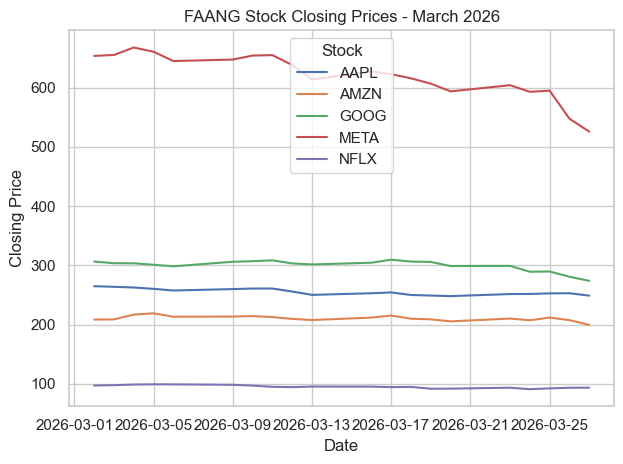

In [80]:
# date is datetime
df["date"] = pd.to_datetime(df["date"])

# Create plot
plt.figure()

sns.lineplot(
    data=df,
    x="date",
    y="close",
    hue="symbol"
)

# Labels and title
plt.title("FAANG Stock Closing Prices - March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Show legend and layout
plt.legend(title="Stock")
plt.tight_layout()

plt.show()

## b

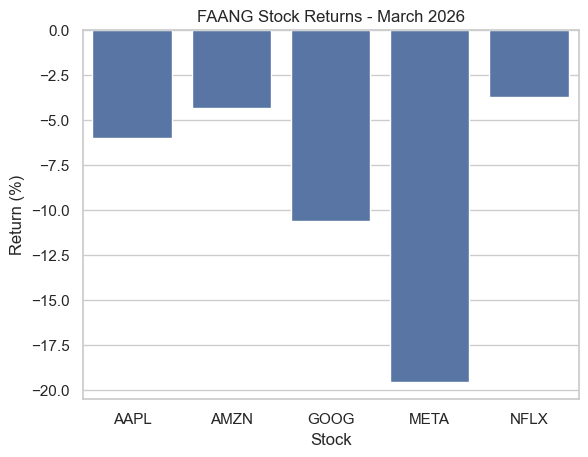

In [81]:
# Reset index so "symbol" becomes a column
plot_data = result.reset_index()

# Create plot
plt.figure()

sns.barplot(
    data=plot_data,
    x="symbol",
    y="return_%"
)

# Labels and title
plt.title("FAANG Stock Returns - March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")

plt.show()

## c

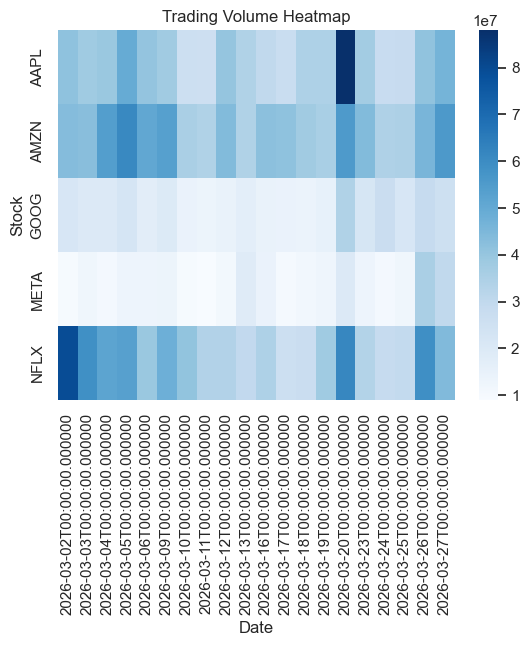

In [82]:
# Pivot table
heatmap_data = df.pivot(index="symbol", columns="date", values="volume")

# Plot
plt.figure()
sns.heatmap(heatmap_data, cmap="Blues")

plt.title("Trading Volume Heatmap")
plt.xlabel("Date")
plt.ylabel("Stock")

plt.show()

## Task 4

## a

In [83]:
import json
import os

# Create a folder
os.makedirs("exports", exist_ok=True)

# Save JSON file
with open("exports/stockdata.json", "w") as f:
    json.dump(data, f)

## b

In [84]:
# Save DataFrame as CSV
df.to_csv("exports/stockdata.csv", index=False)

In [85]:
with open("exports/stockdata.json", "r") as f:
    data_loaded = json.load(f)

# Convert to DataFrame
df_json = pd.DataFrame(data_loaded["data"])

print(df_json.head(5))

     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  262.44  266.53  260.20  264.72  41576035.0    266.53   260.20     264.72   
1  204.55  209.72  203.48  208.39  43410499.0    209.73   203.46     208.39   
2  302.93  308.14  301.06  306.36  21789144.0    308.14   301.06     306.36   
3  637.16  659.94  634.50  653.56   9801700.0    659.94   634.50     653.56   
4   95.33   98.07   95.25   97.09  79614084.0     98.07    95.20      97.09   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0   262.410  41827946.0           1.0       0.0   AAPL     XNAS   
1   204.550  46001010.0           1.0       0.0   AMZN     XNAS   
2   302.965  21854368.0           1.0       0.0   GOOG     XNAS   
3   637.160   9816125.0           1.0       0.0   META     ARCX   
4    95.260  79915361.0           1.0       0.0   NFLX     XNAS   

                       date  
0  2026-03-02T00:00:00+0000  
1  2026-03-02T00:00:00+0000  
2  2026-03-02T00:00:00+0000  
3 

In [86]:
df_csv = pd.read_csv("exports/stockdata.csv")

print(df_csv.head(5))

      open     high     low   close      volume  adj_high  adj_low  adj_close  \
0  262.440  266.530  260.20  264.72  41576035.0   266.530   260.20     264.72   
1  263.480  265.560  260.13  263.75  37994695.0   265.560   260.13     263.75   
2  264.650  266.150  261.42  262.52  39258957.0   266.150   261.42     262.52   
3  260.745  261.555  257.25  260.29  49424671.0   261.555   257.25     260.29   
4  258.740  258.760  254.37  257.46  40628988.0   258.770   254.37     257.46   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    262.41  41827946.0           1.0       0.0   AAPL     XNAS   
1    263.48  38568921.0           1.0       0.0   AAPL     XNAS   
2    264.65  39803119.0           1.0       0.0   AAPL     XNAS   
3    260.79  49658626.0           1.0       0.0   AAPL     XNAS   
4    258.63  41120042.0           1.0       0.0   AAPL     XNAS   

                        date  
0  2026-03-02 00:00:00+00:00  
1  2026-03-03 00:00:00+00:00  
2  2026-03-04 00:

In [87]:
# We check with the old data

print(df.head(5))
# (it does not look identicall, due to sorting)


       open     high     low   close      volume  adj_high  adj_low  \
0   262.440  266.530  260.20  264.72  41576035.0   266.530   260.20   
5   263.480  265.560  260.13  263.75  37994695.0   265.560   260.13   
10  264.650  266.150  261.42  262.52  39258957.0   266.150   261.42   
15  260.745  261.555  257.25  260.29  49424671.0   261.555   257.25   
20  258.740  258.760  254.37  257.46  40628988.0   258.770   254.37   

    adj_close  adj_open  adj_volume  split_factor  dividend symbol exchange  \
0      264.72    262.41  41827946.0           1.0       0.0   AAPL     XNAS   
5      263.75    263.48  38568921.0           1.0       0.0   AAPL     XNAS   
10     262.52    264.65  39803119.0           1.0       0.0   AAPL     XNAS   
15     260.29    260.79  49658626.0           1.0       0.0   AAPL     XNAS   
20     257.46    258.63  41120042.0           1.0       0.0   AAPL     XNAS   

                        date  
0  2026-03-02 00:00:00+00:00  
5  2026-03-03 00:00:00+00:00  
10 20

In [88]:
# Now we check usin code
print(df.sort_values(["symbol", "date"]).reset_index(drop=True)
      .equals(df_csv.sort_values(["symbol", "date"]).reset_index(drop=True)))

False


In [89]:
# I did not understand why i got "false", but Chatgpt helped fixin the date format so now it runs
df["date"] = pd.to_datetime(df["date"])
df_csv["date"] = pd.to_datetime(df_csv["date"])

print(df.sort_values(["symbol", "date"]).reset_index(drop=True)
      .equals(df_csv.sort_values(["symbol", "date"]).reset_index(drop=True)))

True


## Task 5

## a

In [90]:
import sqlite3

# Connect to database
conn = sqlite3.connect("northwind.db")  # change name if your file is different

In [91]:
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()

print(tables)

[('Categories',), ('sqlite_sequence',), ('CustomerCustomerDemo',), ('CustomerDemographics',), ('Customers',), ('Employees',), ('EmployeeTerritories',), ('Order Details',), ('Orders',), ('Products',), ('Regions',), ('Shippers',), ('Suppliers',), ('Territories',)]


## b

In [92]:
query = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;
"""

df_products = pd.read_sql_query(query, conn)

print(df_products)

                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.00             9
12               Côte de Blaye     263.50            17
13                 Ipoh Coffee      46.00            17
14       Manjimup Dried Apples      53.00            20
15               Perth Pasties      32.80             0
16      Gnocchi di nonna Alice      38.00       

## c

In [93]:
query = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c
    ON o.CustomerID = c.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

df_germany = pd.read_sql_query(query, conn)

print(df_germany)

              CompanyName  OrderID            OrderDate ShipCountry  LineTotal
0      Toms Spezialitäten    10249           2016-07-05     Germany      167.4
1      Toms Spezialitäten    10249           2016-07-05     Germany     1696.0
2      Ottilies Käseladen    10260           2016-07-19     Germany      123.2
3      Ottilies Käseladen    10260           2016-07-19     Germany      780.0
4      Ottilies Käseladen    10260           2016-07-19     Germany      591.0
...                   ...      ...                  ...         ...        ...
80668    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      864.0
80669    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      735.0
80670    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       75.0
80671    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      500.0
80672    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       77.5

[80673 rows x 5 columns]


## Task 6

## a

In [94]:
top_customers = (
    df_germany.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

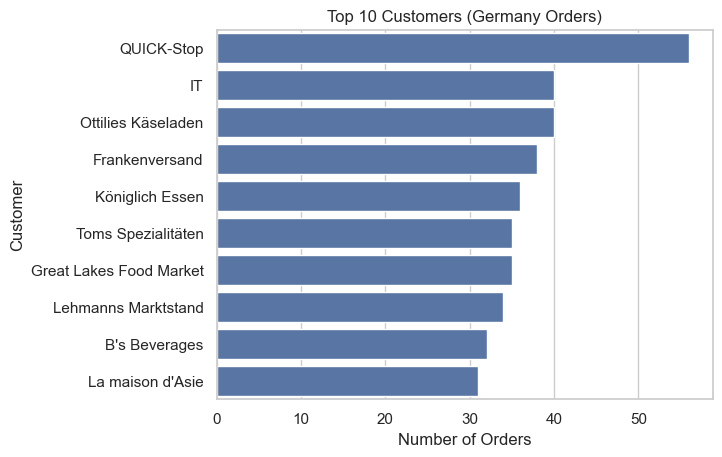

In [95]:
plt.figure()

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.xlabel("Number of Orders")
plt.ylabel("Customer")
plt.title("Top 10 Customers (Germany Orders)")

plt.show()

## b

In [96]:
# Group by date and sum sales
daily_sales = df_germany.groupby("OrderDate")["LineTotal"].sum()

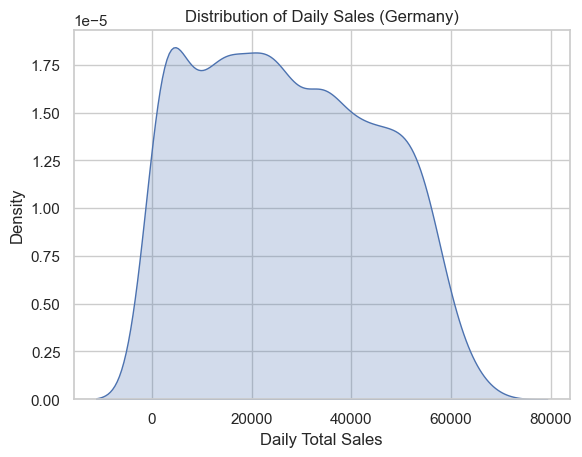

In [97]:
plt.figure()

sns.kdeplot(daily_sales, fill=True)

plt.title("Distribution of Daily Sales (Germany)")
plt.xlabel("Daily Total Sales")

plt.show()

## c

In [98]:
query = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories cat
    ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName;
"""

df_category = pd.read_sql_query(query, conn)

print(df_category)

     CategoryName  TotalRevenue
0       Beverages   92181842.95
1      Condiments   55802774.45
2     Confections   66347544.94
3  Dairy Products   58034940.00
4  Grains/Cereals   28573512.55
5    Meat/Poultry   64896314.41
6         Produce   32706403.90
7         Seafood   49931965.52


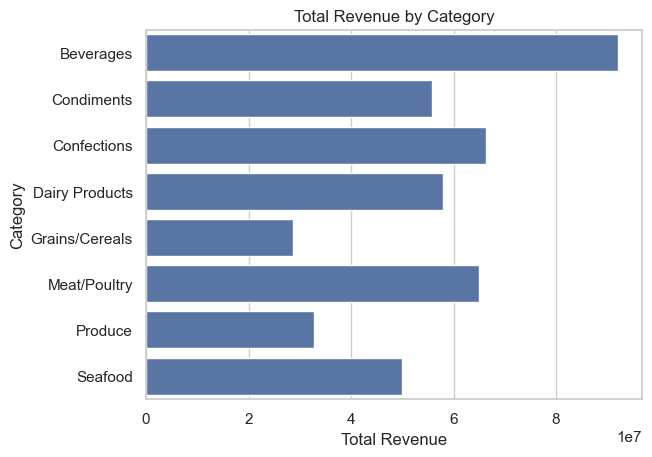

In [99]:
plt.figure()

sns.barplot(
    data=df_category,
    x="TotalRevenue",
    y="CategoryName"
)

plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.title("Total Revenue by Category")

plt.show()

## Task 7

## a

In [100]:
query_products = "SELECT * FROM Products;"
df_products = pd.read_sql_query(query_products, conn)

print(df_products.head(5))

   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3            0  
4            1  


In [101]:
query_categories = "SELECT * FROM Categories;"
df_categories = pd.read_sql_query(query_categories, conn)

print(df_categories.head(5))

   CategoryID    CategoryName  \
0           1       Beverages   
1           2      Condiments   
2           3     Confections   
3           4  Dairy Products   
4           5  Grains/Cereals   

                                         Description  \
0        Soft drinks, coffees, teas, beers, and ales   
1  Sweet and savory sauces, relishes, spreads, an...   
2                Desserts, candies, and sweet breads   
3                                            Cheeses   
4                Breads, crackers, pasta, and cereal   

                                             Picture  
0  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...  


## b

In [102]:
df_joined = pd.merge(df_products, df_categories, on="CategoryID", how="inner")

print(df_joined.head())

   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued CategoryName  \
0            0    Beverages   
1            0    Beverages   
2          

## c

In [103]:
# So first we test the speed of SQL...

In [104]:
import time

start_sql = time.time()

query = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories cat
    ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName;
"""

df_category = pd.read_sql_query(query, conn)

end_sql = time.time()
sql_time = end_sql - start_sql

print("SQL execution time:", sql_time)
print(df_category)

SQL execution time: 2.31943941116333
     CategoryName  TotalRevenue
0       Beverages   92181842.95
1      Condiments   55802774.45
2     Confections   66347544.94
3  Dairy Products   58034940.00
4  Grains/Cereals   28573512.55
5    Meat/Poultry   64896314.41
6         Produce   32706403.90
7         Seafood   49931965.52


In [105]:
# Then we chech for Pandas...

In [106]:
start_py = time.time()

# Load full tables
df_order_details = pd.read_sql_query('SELECT * FROM "Order Details";', conn)
df_products_full = pd.read_sql_query("SELECT * FROM Products;", conn)
df_categories_full = pd.read_sql_query("SELECT * FROM Categories;", conn)

# Join with pandas
df_merge1 = pd.merge(df_order_details, df_products_full, on="ProductID", how="inner")
df_merge2 = pd.merge(df_merge1, df_categories_full, on="CategoryID", how="inner")

# Compute revenue
df_merge2["Revenue"] = df_merge2["UnitPrice_x"] * df_merge2["Quantity"]

# Group by category
df_python_result = df_merge2.groupby("CategoryName")["Revenue"].sum().reset_index()
df_python_result = df_python_result.rename(columns={"Revenue": "TotalRevenue"})

end_py = time.time()
python_time = end_py - start_py

print("Python execution time:", python_time)
print(df_python_result)

Python execution time: 5.87278413772583
     CategoryName  TotalRevenue
0       Beverages   92181842.95
1      Condiments   55802774.45
2     Confections   66347544.94
3  Dairy Products   58034940.00
4  Grains/Cereals   28573512.55
5    Meat/Poultry   64896314.41
6         Produce   32706403.90
7         Seafood   49931965.52


In [107]:
# here you can see both results, and SQL was faster. For me SQL was ~ 1,774 seconds and Pandas was ~ 5,078 seconds.


## Task 8

## a

In [108]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})



In [109]:
print(wide_data)

      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500


In [110]:
long_wide = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print(long_wide)

       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500


## b

In [111]:
print(long_data)

  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130


In [112]:
# Then after
wide_long = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
)

print(wide_long)

product  Laptop  Phone
month                 
Feb          50    110
Jan          45    120
Mar          55    130


## c

In [113]:
# Before (long format from melt)
print(long_wide)

# Back to wide
wide_again = long_wide.pivot(index="store", columns="quarter", values="sales").reset_index()

print(wide_again)

       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500
quarter     store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0        Helsinki     12000     13500     11800     15000
1         Tampere      8500      9100      8800     10200
2           Turku      9200      9800     10100     11500


In [114]:
# Before (wide format from pivot)
print(wide_long)

# Back to long
long_again = wide_long.reset_index().melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

print(long_again)

product  Laptop  Phone
month                 
Feb          50    110
Jan          45    120
Mar          55    130
  month product  units_sold
0   Feb  Laptop          50
1   Jan  Laptop          45
2   Mar  Laptop          55
3   Feb   Phone         110
4   Jan   Phone         120
5   Mar   Phone         130
